In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the CarDekho dataset

df = pd.read_csv("car data.csv")

# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Check dataset information
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (301, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows: 2


In [4]:
# Remove duplicate rows

df = df.drop_duplicates()

# Check the new shape
print("Dataset Shape after removing duplicates:", df.shape)

# Confirm that duplicates are removed
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape after removing duplicates: (299, 9)
Duplicate Rows: 0


In [5]:
# Check unique values in categorical columns

print("Fuel Types:")
print(df["Fuel_Type"].unique())

print("\nSeller Types:")
print(df["Seller_Type"].unique())

print("\nTransmission Types:")
print(df["Transmission"].unique())

Fuel Types:
['Petrol' 'Diesel' 'CNG']

Seller Types:
['Dealer' 'Individual']

Transmission Types:
['Manual' 'Automatic']


In [6]:
# Calculate the age of each car

current_year = 2026

df["Car_Age"] = current_year - df["Year"]

# Display Year and Car_Age
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


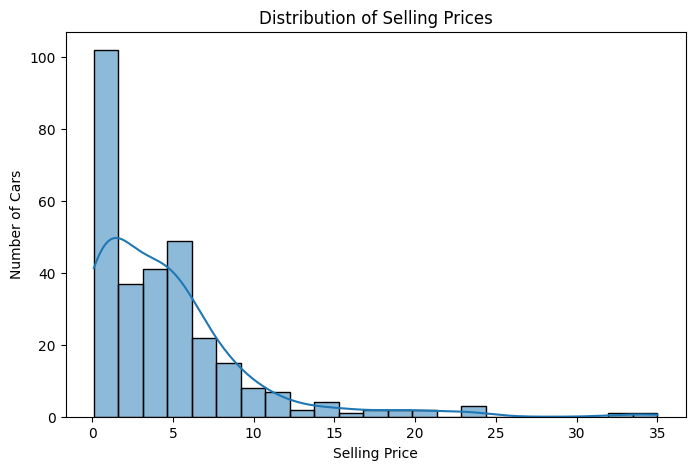

In [8]:
# Distribution of selling prices

plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

### Observation

The selling prices are concentrated mainly in the lower price range, with most cars being sold at relatively lower prices. As the selling price increases, the number of cars decreases significantly. A few cars have much higher selling prices, creating a right-skewed distribution with some high-price outliers.

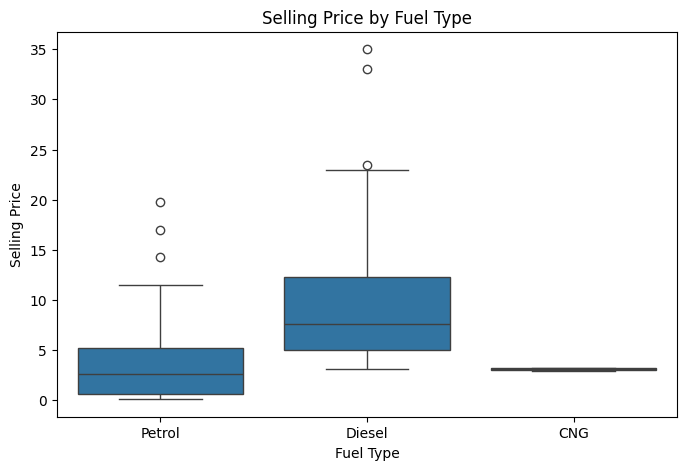

In [9]:
# Selling price by fuel type

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

### Observation

Diesel cars generally have higher selling prices compared with petrol cars. Petrol cars show a wider range of selling prices and several higher-priced outliers. CNG cars have a much smaller price range in this dataset, with selling prices clustered closely together.

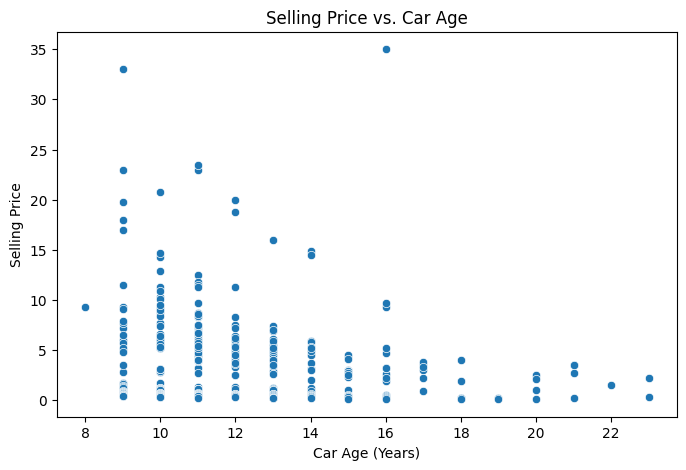

In [10]:
# Selling price vs. car age

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Car_Age", y="Selling_Price")

plt.title("Selling Price vs. Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot shows that older cars generally have lower selling prices. Most cars with lower ages have a wider range of selling prices, including some higher-priced cars. As car age increases, the selling prices are mostly concentrated at lower values, suggesting that car age has a negative relationship with selling price.

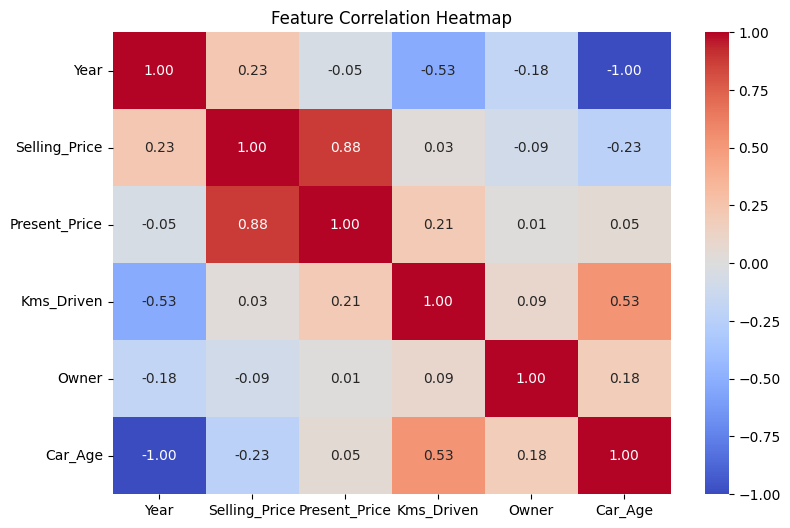

In [11]:
# Feature correlation heatmap

numeric_features = df[
    ["Year", "Selling_Price", "Present_Price", "Kms_Driven", "Owner", "Car_Age"]
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    numeric_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Observation

The heatmap shows that Present Price has a strong positive correlation with Selling Price (0.88), indicating that cars with higher present prices generally have higher selling prices. Car Age has a moderate negative correlation with Selling Price (-0.23), suggesting that older cars tend to have lower selling prices. Kms Driven has very little correlation with Selling Price (0.03) in this dataset. The perfect negative correlation between Year and Car Age (-1.00) is expected because Car Age was calculated directly from Year.

In [14]:
# Encode categorical variables using One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

# Remove columns that are not needed for the model
df_encoded = df_encoded.drop(columns=["Car_Name", "Brand", "Year"])

# Display the encoded dataset
df_encoded.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [15]:
# Define features and target variable

X = df_encoded.drop("Selling_Price", axis=1)
y = df_encoded["Selling_Price"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [16]:
# Train the Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test data
lr_predictions = lr_model.predict(X_test)

# Display the first 5 predictions
print("First 5 Predictions:")
print(lr_predictions[:5])

First 5 Predictions:
[ 7.50192151  7.79152142  1.36644388  7.00941894 11.16328988]


In [17]:
# Evaluate the Linear Regression model

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression Performance
MAE : 1.4728924140033006
RMSE: 2.5240350545947816
R²  : 0.7528154215832914


In [18]:
# Train the Random Forest Regression model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_predictions = rf_model.predict(X_test)

# Display the first 5 predictions
print("First 5 Predictions:")
print(rf_predictions[:5])

First 5 Predictions:
[ 9.4873  8.2615  0.4424  6.9605 16.8175]


In [19]:
# Evaluate the Random Forest model

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regression Performance")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regression Performance
MAE : 1.437946666666668
RMSE: 3.4154391854733226
R²  : 0.547390441726516


In [20]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R²": [lr_r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.472892,2.524035,0.752815
1,Random Forest,1.437947,3.415439,0.547390


In [21]:
# Get feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
feature_importance

,Feature,Importance
0,Present_Price,0.905623
3,Car_Age,0.071841
1,Kms_Driven,0.013396
7,Transmission_Manual,0.005249
6,Seller_Type_Individual,0.002081
5,Fuel_Type_Petrol,0.000914
4,Fuel_Type_Diesel,0.000886
2,Owner,0.000010


### Observation

Present_Price is by far the most important feature in the Random Forest model, with an importance of approximately 90.6%. Car_Age is the second most important feature at about 7.2%, while the remaining features contribute relatively little to the model's predictions.

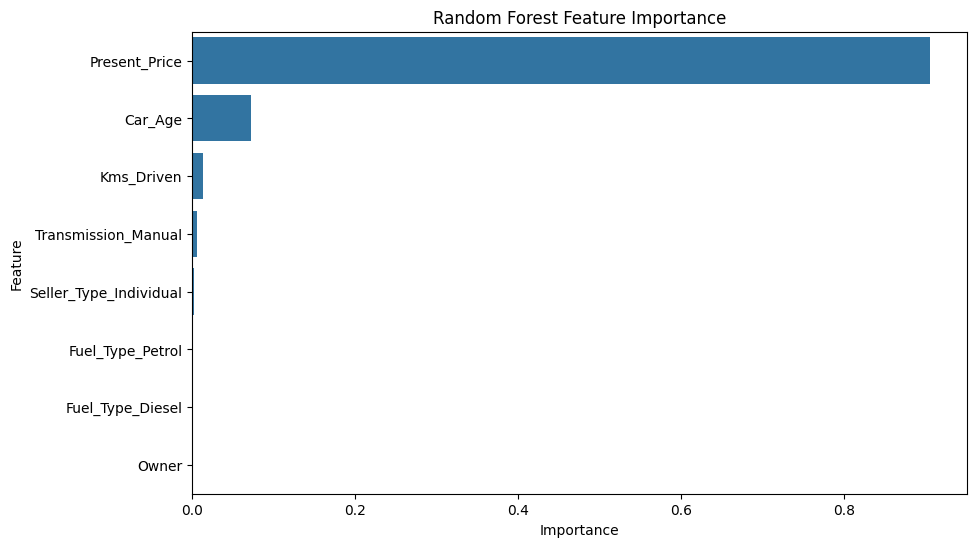

In [22]:
# Visualize feature importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

Present_Price is the most important feature in the Random Forest model, contributing approximately 90.6% of the total feature importance. Car_Age is the second most important feature at around 7.2%, while Kms_Driven and the categorical features have relatively small contributions.

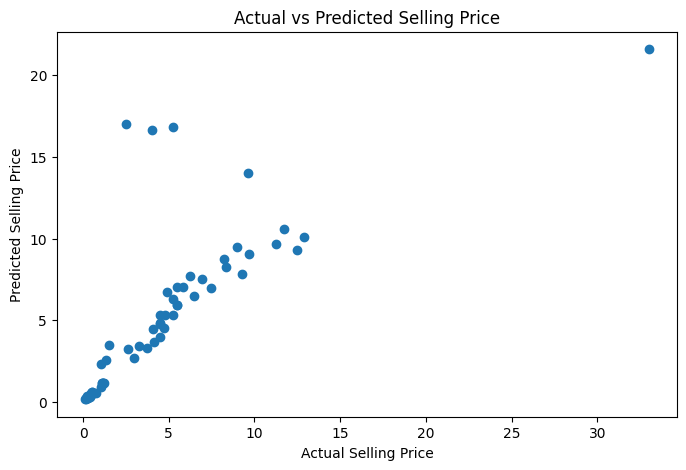

In [23]:
# Compare actual and predicted selling prices

plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

### Observation

The points generally follow an upward trend, showing that the predicted selling prices are reasonably close to the actual selling prices for most cars. However, a few points are noticeably far from the overall pattern, indicating larger prediction errors for some cars, particularly at higher selling prices.

## Conclusion

The used car dataset was analyzed to understand the factors affecting car selling prices. The analysis showed that Present_Price has a strong relationship with Selling_Price, while older cars generally tend to have lower selling prices.

Two machine learning models, Linear Regression and Random Forest Regression, were trained and evaluated using MAE, RMSE, and R². Based on the test results, Linear Regression performed better overall, achieving an R² score of approximately 0.75 and a lower RMSE compared with Random Forest.

The feature importance analysis from Random Forest also showed that Present_Price was the most influential feature in predicting the selling price, followed by Car_Age.

Overall, the project demonstrates how exploratory data analysis and machine learning can be used to understand used car prices and build a model for price prediction.